# CatBoost Hyperparameter Tuning

本 Notebook 承接 `05_feature_engineering_2.ipynb`。Feature Engineering 已固定为 **FE10 + FE25**，这里不再改变输入特征，而是完成 CatBoost 模型配置的最后一轮收敛：先复盘 Reference、Optuna 搜索与锁定 Fold 验证，再确认迭代上限，最后训练全量模型并生成提交文件。

---

## Table of Contents

1. [实验背景与固定协议](#cbt-setup)
2. [Stage A：Reference 一致性检查](#cbt-stage-a)
3. [Stage B：Optuna 参数搜索](#cbt-stage-b)
4. [Stage C：锁定 Fold 3–5 验证](#cbt-stage-c)
5. [最终参数与迭代上限确认](#cbt-iteration)
6. [训练全量模型并生成提交文件](#cbt-final-model)
7. [CatBoost 最终结论与下一步](#cbt-next)
---

<a id="cbt-setup" name="cbt-setup"></a>

## 1. 实验背景与固定协议

`05_feature_engineering_2.ipynb` 最终将 Feature Set 收敛为 **FE10 + FE25**，其 5-Fold CV AUC 为 `0.964704`，Public LB 为 `0.96617`。本阶段只调整 CatBoost 模型参数，所有候选继续使用相同特征、相同五折和相同 Reference。

| 固定项目 | 设置 |
|---|---|
| Feature Set | FE10 + FE25 |
| CV | `StratifiedKFold(5, shuffle=True, random_state=42)` |
| Objective | `Logloss` |
| Evaluation metric | `AUC` |
| Maximum iterations | 10000 |
| Early stopping | 200 |
| Thread count | 10 |
| Reference | CatBoost v4 |

Stage B 只使用 Fold 1–2 搜索参数；Stage C 使用未参与搜索的 Fold 3–5 检查泛化方向。Public LB 不参与参数选择。


In [1]:
import json
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.experiment import CAT_COLS, CV_PARAMS, THREAD_COUNT
from src.round2_features import make_round2_features

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "catboost_tuning"
ROUND2_SINGLE_DIR = PROJECT_ROOT / "results" / "round2" / "r_group_single"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"

REFERENCE_CHECK_PATH = RESULTS_DIR / "reference_check.json"
SEARCH_SUMMARY_PATH = RESULTS_DIR / "search_summary.csv"
FULL_CV_SUMMARY_PATH = RESULTS_DIR / "full_cv_summary.csv"
BEST_VALIDATION_PATH = RESULTS_DIR / "best_validation_params.json"
TRIALS_DIR = RESULTS_DIR / "trials"
CONFIRMATION_PATH = RESULTS_DIR / "iteration_confirmation.csv"


<a id="cbt-stage-a" name="cbt-stage-a"></a>

## 2. Stage A：Reference 一致性检查

参数搜索开始前，先用当前 v4 的有效参数重新训练 Fold 1–2。只有新运行结果与已保存的 FE10 + FE25 Reference 一致，后续 delta 才具有可比性。


In [2]:
if not REFERENCE_CHECK_PATH.exists():
    raise FileNotFoundError(f"缺少 Stage A 结果：{REFERENCE_CHECK_PATH}")

reference_check = json.loads(REFERENCE_CHECK_PATH.read_text(encoding="utf-8"))
if not reference_check["passed"]:
    raise ValueError("Stage A Reference 一致性检查未通过。")

reference_table = (
    pd.DataFrame(reference_check["folds"])[
        ["fold", "auc", "reference_auc", "delta_vs_reference", "best_iteration", "elapsed_seconds"]
    ]
    .rename(columns={
        "fold": "Fold",
        "auc": "复现 AUC",
        "reference_auc": "已保存 Reference AUC",
        "delta_vs_reference": "差值",
        "best_iteration": "最佳迭代数",
        "elapsed_seconds": "耗时（秒）",
    })
)

display(reference_table.style.format({
    "复现 AUC": "{:.6f}",
    "已保存 Reference AUC": "{:.6f}",
    "差值": "{:+.6f}",
    "耗时（秒）": "{:.1f}",
}))
print("Stage A passed:", reference_check["passed"])


,Fold,复现 AUC,已保存 Reference AUC,差值,最佳迭代数,耗时（秒）
0,1,0.964019,0.964019,+0.000000,7396,664.4
1,2,0.964568,0.964568,+0.000000,8853,767.8


Stage A passed: True


Fold 1–2 的复现 AUC 与已保存 Reference 完全一致，差值均为 `0`。这说明 FE10 + FE25、数据划分、类别列处理和 CatBoost 有效默认参数均已对齐，Stage B 可以把每个候选的 AUC 直接与同 Fold v4 比较。


<a id="cbt-stage-b" name="cbt-stage-b"></a>

## 3. Stage B：Optuna 参数搜索

Stage B 在 Fold 1–2 上运行 20 个 Trial，搜索五个参数：`depth`、`learning_rate`、`l2_leaf_reg`、`random_strength` 和 `subsample`。Objective 是两折相对 v4 的平均 paired delta。

MVS bootstrap 保持固定，避免把采样机制变化与普通参数变化混在一起。所有 Trial 顺序执行，每个 CatBoost 模型使用 10 个 CPU 线程。


,trial_number,mean_auc,mean_delta,positive_folds,depth,learning_rate,l2_leaf_reg,random_strength,subsample
0,14,0.964415,+0.000122,2,5,0.069203,11.3491,2.6557,0.7391
1,13,0.964402,+0.000108,2,5,0.069183,10.2963,2.1750,0.6340
2,15,0.964376,+0.000083,2,5,0.067620,3.2089,2.7480,0.7826
3,0,0.964375,+0.000082,2,5,0.077313,12.0571,1.0402,0.6624
4,19,0.964369,+0.000075,2,6,0.070244,7.5790,2.8088,0.6533
5,12,0.964355,+0.000061,2,6,0.066805,10.0819,1.8471,0.6066
6,16,0.964338,+0.000045,2,6,0.059627,14.6508,4.9185,0.8753
7,18,0.964329,+0.000035,1,5,0.057802,3.8565,1.4820,0.8421
8,17,0.964300,+0.000007,2,5,0.073192,26.6637,2.5211,0.7429
9,11,0.964294,+0.000001,1,6,0.063776,8.3870,1.9682,0.6017


完整 Trial 数： 20
Mean Δ > 0： 10
Fold 1–2 均正向： 8
累计模型训练耗时：6.54 小时


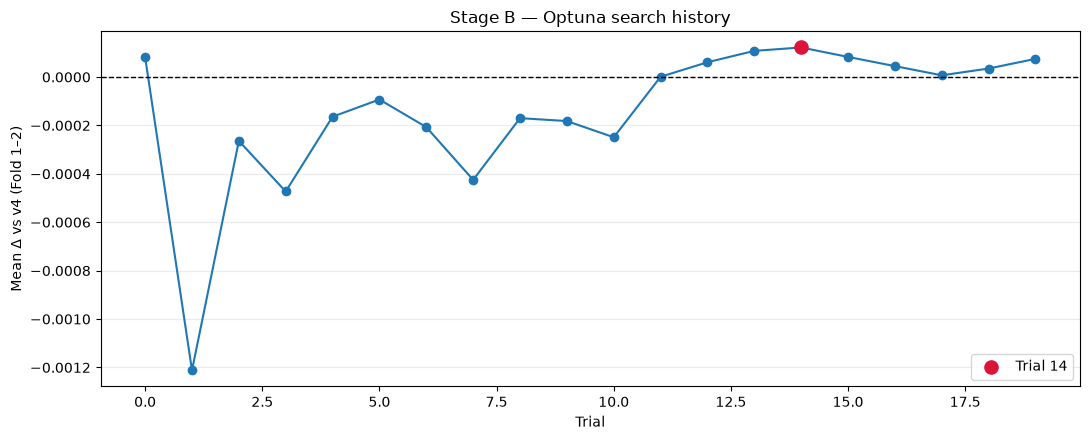

In [3]:
if not SEARCH_SUMMARY_PATH.exists():
    raise FileNotFoundError(f"缺少 Stage B 汇总：{SEARCH_SUMMARY_PATH}")

search_summary = pd.read_csv(SEARCH_SUMMARY_PATH)
search_trials = (
    search_summary[search_summary["source"] == "optuna"]
    .sort_values("mean_delta", ascending=False)
    .copy()
)

search_display = search_trials[[
    "trial_number", "mean_auc", "mean_delta", "positive_folds",
    "depth", "learning_rate", "l2_leaf_reg",
    "random_strength", "subsample",
]].head(10)

display(search_display.style.format({
    "mean_auc": "{:.6f}",
    "mean_delta": "{:+.6f}",
    "learning_rate": "{:.6f}",
    "l2_leaf_reg": "{:.4f}",
    "random_strength": "{:.4f}",
    "subsample": "{:.4f}",
}))

trial_paths = sorted(TRIALS_DIR.glob("trial_*.json"))
search_seconds = sum(
    fold["elapsed_seconds"]
    for path in trial_paths
    for fold in json.loads(path.read_text(encoding="utf-8"))["folds"]
)

print("完整 Trial 数：", len(trial_paths))
print("Mean Δ > 0：", int((search_trials["mean_delta"] > 0).sum()))
print("Fold 1–2 均正向：", int((search_trials["positive_folds"] == 2).sum()))
print(f"累计模型训练耗时：{search_seconds / 3600:.2f} 小时")

history = search_trials.sort_values("trial_number")
best_search = search_trials.iloc[0]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(history["trial_number"], history["mean_delta"], marker="o", linewidth=1.5)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.scatter(best_search["trial_number"], best_search["mean_delta"], color="crimson", s=90, zorder=3, label=f"Trial {int(best_search['trial_number'])}")
ax.set(title="Stage B — Optuna search history", xlabel="Trial", ylabel="Mean Δ vs v4 (Fold 1–2)")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


20 个 Trial 全部完成，其中 10 个 Mean Δ 为正、8 个在 Fold 1–2 上均为正。优胜区域集中在较浅的 `depth=5`、约 `0.067–0.070` 的学习率和更强的正则化。

Trial 14 是搜索阶段第一名，Fold 1–2 Mean Δ 为 `+0.000122`。但它是从 20 个候选中选出的搜索赢家，仍可能偏向这两个 Fold，因此这里只把 Trial 14、13、15 晋级到锁定验证，不直接确定最终模型。Stage B 的 40 次 Fold 训练累计约 **6 小时 32 分**。


<a id="cbt-stage-c" name="cbt-stage-c"></a>

## 4. Stage C：锁定 Fold 3–5 验证

Stage C 不再搜索参数，只把 Stage B 排名前三的 Trial 14、13、15 放到 Fold 3–5。候选需要同时满足：

1. Fold 3–5 Mean Δ > 0；
2. Fold 3–5 至少 2/3 正向；
3. 完整 5-Fold Mean Δ > 0；
4. 完整五折至少 4/5 正向。

最终排序优先看未参与参数搜索的 Fold 3–5，而不是继续奖励 Fold 1–2 上的搜索优势。


,Trial,Fold 3–5 Mean Δ,Fold 3–5 正向数,5-Fold AUC,5-Fold Mean Δ,5-Fold 正向数,平均最佳迭代数,通过
0,13,+0.000050,3,0.964777,+0.000073,5,9069.0,True
1,15,+0.000023,2,0.964750,+0.000047,4,8566.6,True
2,14,+0.000021,2,0.964765,+0.000062,4,8801.6,True


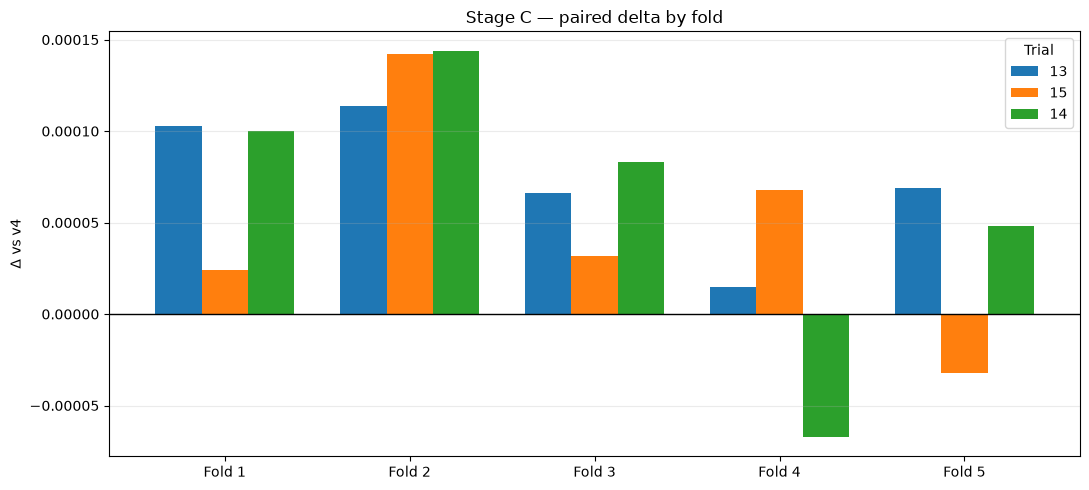

In [4]:
if not FULL_CV_SUMMARY_PATH.exists():
    raise FileNotFoundError(f"缺少 Stage C 汇总：{FULL_CV_SUMMARY_PATH}")

full_cv = pd.read_csv(FULL_CV_SUMMARY_PATH)
full_cv = full_cv.sort_values("validation_mean_delta", ascending=False)

validation_display = full_cv[[
    "trial_number", "validation_mean_delta", "validation_positive_folds",
    "mean_auc", "mean_delta", "positive_folds",
    "mean_best_iteration", "passes_validation",
]].rename(columns={
    "trial_number": "Trial",
    "validation_mean_delta": "Fold 3–5 Mean Δ",
    "validation_positive_folds": "Fold 3–5 正向数",
    "mean_auc": "5-Fold AUC",
    "mean_delta": "5-Fold Mean Δ",
    "positive_folds": "5-Fold 正向数",
    "mean_best_iteration": "平均最佳迭代数",
    "passes_validation": "通过",
})

display(validation_display.style.format({
    "Fold 3–5 Mean Δ": "{:+.6f}",
    "5-Fold AUC": "{:.6f}",
    "5-Fold Mean Δ": "{:+.6f}",
    "平均最佳迭代数": "{:.1f}",
}))

fold_delta_columns = [f"fold{fold}_delta" for fold in range(1, 6)]
fold_delta_plot = full_cv.set_index("trial_number")[fold_delta_columns].T
fold_delta_plot.index = [f"Fold {fold}" for fold in range(1, 6)]

ax = fold_delta_plot.plot(kind="bar", figsize=(11, 5), width=0.75)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Stage C — paired delta by fold", xlabel="", ylabel="Δ vs v4")
ax.legend(title="Trial")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


三个候选都通过预先定义的 Stage C 规则，但 Trial 13 在锁定 Fold 上最强：Fold 3–5 Mean Δ 为 `+0.000050`，3/3 正向；完整 5-Fold AUC 为 `0.964777`，相对 v4 提升 `+0.000073`，5/5 正向。

Trial 14 从 Stage B 的第一名下降到锁定验证第三名，说明单纯继续优化 Fold 1–2 会放大搜索赢家偏差。最终参数因此固定为 **Trial 13**，CatBoost 不再继续增加 Optuna Trial。


<a id="cbt-iteration" name="cbt-iteration"></a>

## 5. 最终参数与迭代上限确认

Trial 13 的 Fold 1 最佳迭代数为 `9992`，已经接近 Stage B/C 的 `10000` 上限。因此不能直接把当前五折平均值 `9069` 当作全量训练轮数。

这里固定 Trial 13 的全部参数，只把最大迭代数提高到 `15000`，继续使用相同五折和 `early_stopping_rounds=200`。这一步不是重新搜索参数，而是检查原上限是否截断了最佳轮数。


In [5]:
if not BEST_VALIDATION_PATH.exists():
    raise FileNotFoundError(f"缺少最终验证参数：{BEST_VALIDATION_PATH}")

best_validation = json.loads(BEST_VALIDATION_PATH.read_text(encoding="utf-8"))
FINAL_TRIAL = int(best_validation["trial_number"])
FINAL_PARAMS = best_validation["params"].copy()
CONFIRMATION_MAX_ITERATIONS = 15000

params_table = pd.Series(FINAL_PARAMS, name="值").rename_axis("参数").to_frame()
display(params_table)
print("最终 Trial：", FINAL_TRIAL)
print("迭代确认上限：", CONFIRMATION_MAX_ITERATIONS)


,值
参数,
depth,5.000000
learning_rate,0.069183
l2_leaf_reg,10.296349
random_strength,2.175034
subsample,0.634014


最终 Trial： 13
迭代确认上限： 15000


### 5.1 准备五折确认数据


In [6]:
train_confirmation = pd.read_csv(DATA_DIR / "train.csv")
X_confirmation = train_confirmation.drop(columns=["addicted_label", "id"]).copy()
y_confirmation = train_confirmation["addicted_label"].copy()
X_confirmation = make_round2_features(X_confirmation, "FE25")

for col in CAT_COLS:
    X_confirmation[col] = X_confirmation[col].fillna("Missing")

splitter = StratifiedKFold(**CV_PARAMS)
confirmation_folds = list(splitter.split(X_confirmation, y_confirmation))

print("训练数据形状：", X_confirmation.shape)
print("确认 Fold 数：", len(confirmation_folds))


训练数据形状： (691369, 14)
确认 Fold 数： 5


### 5.2 运行 15000 上限的五折确认

结果会在每个 Fold 完成后写入 `results/catboost_tuning/iteration_confirmation.csv`。如果运行中断，重新执行本单元会自动跳过已经完成的 Fold。


In [7]:
if CONFIRMATION_PATH.exists():
    confirmation_results = pd.read_csv(CONFIRMATION_PATH).to_dict("records")
else:
    confirmation_results = []

completed_folds = {int(result["fold"]) for result in confirmation_results}

for fold, (train_idx, valid_idx) in enumerate(confirmation_folds, start=1):
    if fold in completed_folds:
        print(f"Fold {fold}: already completed")
        continue

    X_train = X_confirmation.iloc[train_idx]
    X_valid = X_confirmation.iloc[valid_idx]
    y_train = y_confirmation.iloc[train_idx]
    y_valid = y_confirmation.iloc[valid_idx]

    model = CatBoostClassifier(
        iterations=CONFIRMATION_MAX_ITERATIONS,
        **FINAL_PARAMS,
        bootstrap_type="MVS",
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        thread_count=THREAD_COUNT,
        verbose=500,
        allow_writing_files=False,
    )

    started_at = perf_counter()
    model.fit(
        X_train,
        y_train,
        cat_features=CAT_COLS,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=200,
    )
    elapsed_seconds = perf_counter() - started_at

    valid_pred = model.predict_proba(X_valid)[:, 1]
    auc = float(roc_auc_score(y_valid, valid_pred))
    reference_path = ROUND2_SINGLE_DIR / f"fe25_fold{fold}.json"
    reference = json.loads(reference_path.read_text(encoding="utf-8"))
    reference_auc = float(reference["auc"])

    confirmation_results.append({
        "fold": fold,
        "auc": auc,
        "reference_auc": reference_auc,
        "delta_vs_reference": auc - reference_auc,
        "best_iteration": model.get_best_iteration() + 1,
        "elapsed_seconds": round(elapsed_seconds, 1),
    })

    confirmation = pd.DataFrame(confirmation_results).sort_values("fold")
    confirmation.to_csv(CONFIRMATION_PATH, index=False)
    print(f"Fold {fold}: AUC={auc:.6f}, Δ={auc - reference_auc:+.6f}")


0:	test: 0.8975840	best: 0.8975840 (0)	total: 144ms	remaining: 36m 5s
500:	test: 0.9518120	best: 0.9518120 (500)	total: 35s	remaining: 16m 52s
1000:	test: 0.9574313	best: 0.9574313 (1000)	total: 1m 10s	remaining: 16m 29s
1500:	test: 0.9599650	best: 0.9599650 (1500)	total: 1m 55s	remaining: 17m 17s
2000:	test: 0.9612066	best: 0.9612066 (2000)	total: 2m 39s	remaining: 17m 14s
2500:	test: 0.9619901	best: 0.9619901 (2500)	total: 3m 14s	remaining: 16m 9s
3000:	test: 0.9625069	best: 0.9625069 (3000)	total: 3m 49s	remaining: 15m 17s
3500:	test: 0.9629428	best: 0.9629428 (3500)	total: 4m 27s	remaining: 14m 37s
4000:	test: 0.9632424	best: 0.9632427 (3999)	total: 5m 4s	remaining: 13m 58s
4500:	test: 0.9634334	best: 0.9634334 (4500)	total: 5m 41s	remaining: 13m 16s
5000:	test: 0.9635674	best: 0.9635674 (4996)	total: 6m 16s	remaining: 12m 32s
5500:	test: 0.9636938	best: 0.9636945 (5499)	total: 6m 52s	remaining: 11m 51s
6000:	test: 0.9637659	best: 0.9637660 (5999)	total: 7m 27s	remaining: 11m 11s
6

### 5.3 汇总确认结果并确定全量训练轮数


In [8]:
if not CONFIRMATION_PATH.exists():
    raise FileNotFoundError("请先完成 15000 上限的五折确认。")

confirmation = pd.read_csv(CONFIRMATION_PATH).sort_values("fold")
if confirmation["fold"].tolist() != list(range(1, 6)):
    raise ValueError("迭代确认尚未完成全部五折。")
if confirmation["best_iteration"].max() >= CONFIRMATION_MAX_ITERATIONS - 1:
    raise ValueError("仍有 Fold 触及 15000 上限，需要继续提高上限后再确定轮数。")

FINAL_ITERATIONS = int(round(confirmation["best_iteration"].mean()))
confirmation_summary = pd.DataFrame({
    "指标": [
        "5-Fold Mean AUC",
        "AUC Std",
        "Mean Δ vs v4",
        "正向 Fold",
        "平均最佳迭代数",
        "最终全量训练轮数",
    ],
    "结果": [
        confirmation["auc"].mean(),
        confirmation["auc"].std(),
        confirmation["delta_vs_reference"].mean(),
        int((confirmation["delta_vs_reference"] > 0).sum()),
        confirmation["best_iteration"].mean(),
        FINAL_ITERATIONS,
    ],
})

display(confirmation)
display(confirmation_summary)
print("最终全量训练轮数：", FINAL_ITERATIONS)


,fold,auc,reference_auc,delta_vs_reference,best_iteration,elapsed_seconds
0,1,0.964142,0.964019,0.000123,10613,799.8
1,2,0.964682,0.964568,0.000114,8753,667.7
2,3,0.964869,0.964803,0.000066,8099,644.7
3,4,0.965628,0.965613,0.000015,9286,687.9
4,5,0.964584,0.964515,0.000069,9215,631.9


,指标,结果
0,5-Fold Mean AUC,0.964781
1,AUC Std,0.000544
2,Mean Δ vs v4,0.000078
3,正向 Fold,5.000000
4,平均最佳迭代数,9193.200000
5,最终全量训练轮数,9193.000000


最终全量训练轮数： 9193


<a id="cbt-final-model" name="cbt-final-model"></a>

## 6. 训练全量模型并生成提交文件

迭代确认完成后，用五折最佳迭代数的均值固定全量训练轮数。全量模型不再提供 `eval_set`，也不使用 early stopping；特征和 Trial 13 参数保持不变。


### 6.1 准备全量训练与测试数据


In [9]:
confirmation = pd.read_csv(CONFIRMATION_PATH).sort_values("fold")
if confirmation["fold"].tolist() != list(range(1, 6)):
    raise ValueError("迭代确认尚未完成全部五折。")
if confirmation["best_iteration"].max() >= CONFIRMATION_MAX_ITERATIONS - 1:
    raise ValueError("仍有 Fold 触及迭代上限，暂不训练全量模型。")

FINAL_ITERATIONS = int(round(confirmation["best_iteration"].mean()))
best_validation = json.loads(BEST_VALIDATION_PATH.read_text(encoding="utf-8"))
FINAL_PARAMS = best_validation["params"].copy()

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

X_final = train.drop(columns=["addicted_label", "id"]).copy()
y_final = train["addicted_label"].copy()
X_test_final = test.drop(columns=["id"]).copy()
original_columns = list(X_final.columns)

X_final = make_round2_features(X_final, "FE25")
X_test_final = make_round2_features(X_test_final, "FE25")
added_columns = [col for col in X_final.columns if col not in original_columns]
expected_added_columns = [
    "unknown_activity_time",
    "screen_minus_gaming_work_study",
]

if added_columns != expected_added_columns:
    raise ValueError(f"最终新增特征不符合预期：{added_columns}")
if list(X_final.columns) != list(X_test_final.columns):
    raise ValueError("训练集与测试集的最终特征列不一致。")
if not test["id"].equals(sample_submission["id"]):
    raise ValueError("test.csv 与 sample_submission.csv 的 id 顺序不一致。")

for col in CAT_COLS:
    X_final[col] = X_final[col].fillna("Missing")
    X_test_final[col] = X_test_final[col].fillna("Missing")

print("训练集特征形状：", X_final.shape)
print("测试集特征形状：", X_test_final.shape)
print("最终 Feature Set：FE10 + FE25")
print("最终训练轮数：", FINAL_ITERATIONS)


训练集特征形状： (691369, 14)
测试集特征形状： (296302, 14)
最终 Feature Set：FE10 + FE25
最终训练轮数： 9193


### 6.2 训练最终 CatBoost 模型


In [10]:
final_model = CatBoostClassifier(
    iterations=FINAL_ITERATIONS,
    **FINAL_PARAMS,
    bootstrap_type="MVS",
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    thread_count=THREAD_COUNT,
    verbose=500,
    allow_writing_files=False,
)

final_model.fit(
    X_final,
    y_final,
    cat_features=CAT_COLS,
)

feature_importance_final = (
    pd.DataFrame({
        "特征": X_final.columns,
        "重要性": final_model.feature_importances_,
    })
    .sort_values("重要性", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_final.head(15))


0:	total: 77.2ms	remaining: 11m 49s
500:	total: 38.3s	remaining: 11m 4s
1000:	total: 1m 16s	remaining: 10m 25s
1500:	total: 1m 54s	remaining: 9m 45s
2000:	total: 2m 31s	remaining: 9m 4s
2500:	total: 3m 9s	remaining: 8m 26s
3000:	total: 3m 47s	remaining: 7m 49s
3500:	total: 4m 25s	remaining: 7m 11s
4000:	total: 5m 2s	remaining: 6m 32s
4500:	total: 5m 41s	remaining: 5m 56s
5000:	total: 6m 21s	remaining: 5m 20s
5500:	total: 7m 1s	remaining: 4m 42s
6000:	total: 7m 39s	remaining: 4m 4s
6500:	total: 8m 17s	remaining: 3m 25s
7000:	total: 8m 54s	remaining: 2m 47s
7500:	total: 9m 31s	remaining: 2m 8s
8000:	total: 10m 9s	remaining: 1m 30s
8500:	total: 10m 46s	remaining: 52.6s
9000:	total: 11m 23s	remaining: 14.6s
9192:	total: 11m 37s	remaining: 0us


,特征,重要性
0,daily_screen_time_hours,24.448619
1,weekend_screen_time,21.721430
2,social_media_hours,15.668951
3,notifications_per_day,13.260276
4,app_opens_per_day,11.224925
5,work_study_hours,3.383924
6,screen_minus_gaming_work_study,2.677380
7,gaming_hours,2.616544
8,unknown_activity_time,1.969932
9,sleep_hours,1.709197


### 6.3 生成、检查并保存 v5 Submission


In [11]:
test_pred_final = final_model.predict_proba(X_test_final)[:, 1]

submission_final = sample_submission.copy()
submission_final["addicted_label"] = test_pred_final

submission_check = pd.DataFrame({
    "检查项": [
        "提交行数",
        "ID 是否唯一",
        "ID 是否与 test 顺序一致",
        "预测缺失数",
        "最小预测概率",
        "最大预测概率",
    ],
    "结果": [
        len(submission_final),
        submission_final["id"].is_unique,
        submission_final["id"].equals(test["id"]),
        submission_final["addicted_label"].isna().sum(),
        submission_final["addicted_label"].min(),
        submission_final["addicted_label"].max(),
    ],
})

if len(submission_final) != len(test):
    raise ValueError("提交文件行数与测试集不一致。")
if not submission_final["id"].is_unique:
    raise ValueError("提交文件存在重复 ID。")
if submission_final["addicted_label"].isna().any():
    raise ValueError("提交预测中存在缺失值。")
if not submission_final["addicted_label"].between(0, 1).all():
    raise ValueError("提交预测超出 [0, 1]。")

SUBMISSION_DIR.mkdir(exist_ok=True)
submission_path = (
    SUBMISSION_DIR
    / f"catboost_v5_fe10_fe25_optuna_{FINAL_ITERATIONS}iter.csv"
)
submission_final.to_csv(submission_path, index=False)

display(submission_final.head())
display(submission_check)
print("提交文件已保存到：", submission_path)


,id,addicted_label
0,691369,0.999686
1,691370,0.958679
2,691371,0.922128
3,691372,0.989980
4,691373,0.998988


,检查项,结果
0,提交行数,296302
1,ID 是否唯一,True
2,ID 是否与 test 顺序一致,True
3,预测缺失数,0
4,最小预测概率,0.000028
5,最大预测概率,1.0


提交文件已保存到： /Users/c.c./Developer/Competitions/predicting-smartphone-addiction/submissions/catboost_v5_fe10_fe25_optuna_9193iter.csv


<a id="cbt-next" name="cbt-next"></a>

## 7. CatBoost 最终结论与下一步

Feature Engineering 在 FE10 + FE25 收口，模型参数搜索则通过 Stage A 的一致性检查、Stage B 的 20-Trial Optuna 搜索和 Stage C 的锁定 Fold 验证收敛到 Trial 13。其完整 5-Fold AUC 为 `0.964777`，相对 v4 提升 `+0.000073`，5/5 Fold 正向。

迭代上限确认解决 Trial 13 接近 10000 轮边界的问题，最终按五折最佳迭代数均值固定训练 **9193 iterations**。提交文件 `catboost_v5_fe10_fe25_optuna_9193iter.csv` 获得 Public LB **0.96612**，较 v4 的 `0.96617` 低 `0.00005`，这次 Kaggle 外部验证未复现本地 CV 的微小增益。

![CatBoost v5 with FE10 + FE25 and Optuna tuning — Public LB 0.96612](../images/catboost_v5_fe10_fe25_optuna_9193_public_lb.png)

*Submission result for `catboost_v5_fe10_fe25_optuna_9193iter.csv`.*

CatBoost 的特征与参数调优主线到此结束；后续实验转向 LightGBM、XGBoost、统一 OOF 预测和 Ensemble，而不是继续在相同 Fold 上追加 CatBoost Trial。
